# 04 EFE With State-Dependent Observation

This is the thesis-mechanism notebook.

Locked question:
- If observation quality depends on robot state, does the planner change its behavior **purely because the observation model changed**?

This notebook is designed to answer exactly that question and nothing larger.


## What Changes, What Does Not, And Why That Matters

Held fixed:
- state definition `z = [x, y, theta]`,
- dynamics model,
- goal prior,
- action library,
- risk / ambiguity / control structure.

Changed:

```math
R \; \longrightarrow \; R_{\mathrm{eff}}(x) = q(x) R_{\mathrm{good}} + (1-q(x)) R_{\mathrm{bad}}
```

Explicitly excluded here:
- no extra visibility reward,
- no explicit penalty term `w_vis (1-q)`,
- no extra covariance inflation heuristic,
- no gain scaling trick.

Why this is a strong experimental design:
- the first comparison is falsifiable,
- behavior change can be attributed to the observation model,
- later learned and occupancy-map variants can be compared against the same clean baseline.


In [7]:
from pathlib import Path
import sys

repo_root = Path.cwd()
if not (repo_root / "scripts").exists():
    repo_root = repo_root.parent
if str(repo_root) not in sys.path:
    sys.path.append(str(repo_root))

import numpy as np
import matplotlib.pyplot as plt

from scripts.state_dependent_observation_helpers import (
    covariance_logdet_series,
    covariance_trace_series,
    evaluate_q_field_on_grid,
    grid_states,
    make_action_library,
    make_default_camera,
    make_observation_fn,
    observation_covariance,
    process_covariance_from_rho,
    radial_drop_q,
    score_action_library,
    simulate_receding_horizon,
)

plt.rcParams["figure.figsize"] = (7, 5)
plt.rcParams["axes.grid"] = True

dt = 0.2
rho = np.array([1e-2, 1e-2], dtype=float)
risk_weight = 1.0
ambiguity_weight = 1.0
control_weight = 0.10

camera = make_default_camera()
g = make_observation_fn(camera, obs_mode="uv")
Q = process_covariance_from_rho(dt=dt, rho_xy=rho[0])
R_good = observation_covariance(obs_mode="uv", uv_std=2.5)
R_bad = observation_covariance(obs_mode="uv", uv_std=20.0)
actions = make_action_library(v_values=(0.0, 0.22, 0.35, 0.45), w_values=(-1.2, -0.8, -0.35, 0.0, 0.35, 0.8, 1.2))

mean0 = np.array([-0.8, -0.4, 0.0])
cov0 = np.diag([0.30, 0.30, 0.12])
goal_state = np.array([0.8, 0.4, 0.0])
goal_obs = g(goal_state)
goal_obs_cov = observation_covariance(obs_mode="uv", uv_std=24.0)

# The goal prior is slightly broader than notebook 02 so the observation-model-only effect is visible.
q_fn = lambda s: radial_drop_q(s, center=(0.0, 0.0), radius=1.0, transition=1.0, q_min=0.15)


## Candidate-Level Comparison

The first comparison is at a single planning state.

This is useful because:
- it shows whether the planner ranking changes before any closed-loop simulation,
- it exposes whether ambiguity or risk is responsible,
- it prevents trajectory-level effects from hiding the mechanism.


In [8]:
baseline_candidates = score_action_library(
    mean0,
    cov0,
    actions,
    dt=0.2,
    Q=Q,
    g=g,
    goal_obs=goal_obs,
    goal_obs_cov=goal_obs_cov,
    R_good=R_good,
    R_bad=R_good,
    q_fn=None,
    horizon=8,
    risk_weight=risk_weight,
    ambiguity_weight=ambiguity_weight,
    control_weight=control_weight,
    approx="ET2",
    add_ambiguity=True,
)

oracle_candidates = score_action_library(
    mean0,
    cov0,
    actions,
    dt=0.2,
    Q=Q,
    g=g,
    goal_obs=goal_obs,
    goal_obs_cov=goal_obs_cov,
    R_good=R_good,
    R_bad=R_bad,
    q_fn=q_fn,
    horizon=8,
    risk_weight=risk_weight,
    ambiguity_weight=ambiguity_weight,
    control_weight=control_weight,
    approx="ET2",
    add_ambiguity=True,
)

def describe_candidate(label, item):
    print(
        f"{label}: u={item.control}, total={item.total:.3f}, min_q={item.min_q:.3f}, "
        f"risk_w={item.risk_term:.3f}, amb_w={item.ambiguity_term:.3f}, ctrl_w={item.control_term:.3f}, "
        f"risk_raw={item.risk_raw:.3f}, amb_raw={item.ambiguity_raw:.3f}"
    )

describe_candidate("Best constant-R", baseline_candidates[0])
describe_candidate("Best oracle-R_eff", oracle_candidates[0])


Best constant-R: u=[0.45 0.8 ], total=140.177, min_q=1.000, risk_w=93.740, amb_w=45.764, ctrl_w=0.674, risk_raw=93.740, amb_raw=45.764
Best oracle-R_eff: u=[0.45 0.35], total=167.548, min_q=0.150, risk_w=97.650, amb_w=69.638, ctrl_w=0.260, risk_raw=97.650, amb_raw=69.638


In [9]:
baseline_run = simulate_receding_horizon(
    mean0,
    cov0,
    actions,
    dt=0.2,
    Q=Q,
    g=g,
    goal_obs=goal_obs,
    goal_obs_cov=goal_obs_cov,
    R_good=R_good,
    R_bad=R_good,
    q_fn=None,
    horizon=8,
    n_steps=18,
    risk_weight=risk_weight,
    ambiguity_weight=ambiguity_weight,
    control_weight=control_weight,
    approx="ET2",
    add_ambiguity=True,
)

oracle_run = simulate_receding_horizon(
    mean0,
    cov0,
    actions,
    dt=0.2,
    Q=Q,
    g=g,
    goal_obs=goal_obs,
    goal_obs_cov=goal_obs_cov,
    R_good=R_good,
    R_bad=R_bad,
    q_fn=q_fn,
    horizon=8,
    n_steps=18,
    risk_weight=risk_weight,
    ambiguity_weight=ambiguity_weight,
    control_weight=control_weight,
    approx="ET2",
    add_ambiguity=True,
)

xs, ys, states = grid_states(xmin=-2.5, xmax=2.5, ymin=-2.5, ymax=2.5, nx=121, ny=121)
q_map = evaluate_q_field_on_grid(q_fn, states)
extent = [xs.min(), xs.max(), ys.min(), ys.max()]


## How To Read The Main Comparison Plots

Read these figures in this order:
1. trajectory overlay on top of `q(x)`,
2. covariance trace / logdet over time,
3. ambiguity and risk traces,
4. best-candidate raw vs weighted bar plots.

A convincing result here is not just "the score changed". A convincing result is:
- action ranking changed,
- the closed-loop path or pose choice changed,
- the change is explainable through `R_eff(x)` and the ambiguity/risk terms.


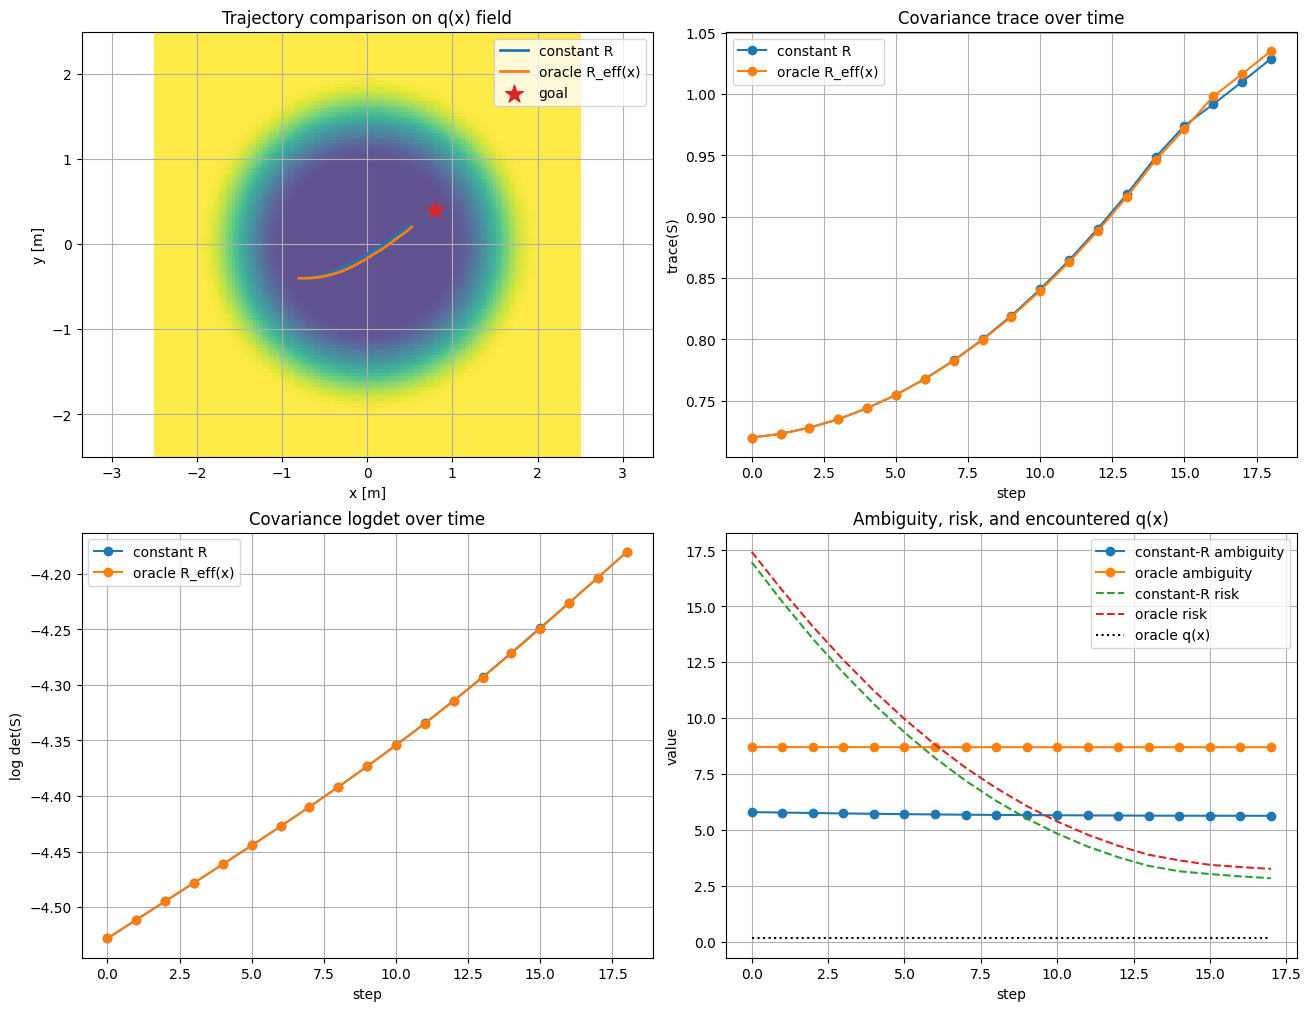

Constant-R final state: [0.49643324 0.22177047 0.65      ]
Oracle final state:     [0.52359206 0.20339679 0.7       ]
Constant-R path length: 1.4620000000000002
Oracle path length:     1.4880000000000002
Mean oracle q(x):       0.15
Minimum oracle q(x):    0.15


In [10]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10), constrained_layout=True)

axes[0, 0].imshow(q_map, origin="lower", extent=extent, vmin=0.0, vmax=1.0, cmap="viridis", alpha=0.85)
axes[0, 0].plot(baseline_run["means"][:, 0], baseline_run["means"][:, 1], label="constant R", linewidth=2)
axes[0, 0].plot(oracle_run["means"][:, 0], oracle_run["means"][:, 1], label="oracle R_eff(x)", linewidth=2)
axes[0, 0].scatter(goal_state[0], goal_state[1], marker="*", s=180, color="tab:red", label="goal")
axes[0, 0].set_title("Trajectory comparison on q(x) field")
axes[0, 0].set_xlabel("x [m]")
axes[0, 0].set_ylabel("y [m]")
axes[0, 0].legend(loc="best")
axes[0, 0].axis("equal")

axes[0, 1].plot(covariance_trace_series(baseline_run["covs"]), label="constant R", marker="o")
axes[0, 1].plot(covariance_trace_series(oracle_run["covs"]), label="oracle R_eff(x)", marker="o")
axes[0, 1].set_title("Covariance trace over time")
axes[0, 1].set_xlabel("step")
axes[0, 1].set_ylabel("trace(S)")
axes[0, 1].legend()

axes[1, 0].plot(covariance_logdet_series(baseline_run["covs"]), label="constant R", marker="o")
axes[1, 0].plot(covariance_logdet_series(oracle_run["covs"]), label="oracle R_eff(x)", marker="o")
axes[1, 0].set_title("Covariance logdet over time")
axes[1, 0].set_xlabel("step")
axes[1, 0].set_ylabel("log det(S)")
axes[1, 0].legend()

axes[1, 1].plot(baseline_run["ambiguity_terms"], label="constant-R ambiguity", marker="o")
axes[1, 1].plot(oracle_run["ambiguity_terms"], label="oracle ambiguity", marker="o")
axes[1, 1].plot(baseline_run["risk_terms"], label="constant-R risk", linestyle="--")
axes[1, 1].plot(oracle_run["risk_terms"], label="oracle risk", linestyle="--")
axes[1, 1].plot(oracle_run["q_values"], label="oracle q(x)", linestyle=":", color="black")
axes[1, 1].set_title("Ambiguity, risk, and encountered q(x)")
axes[1, 1].set_xlabel("step")
axes[1, 1].set_ylabel("value")
axes[1, 1].legend()

plt.show()

def path_length(states):
    diffs = np.diff(states[:, :2], axis=0)
    return float(np.sum(np.linalg.norm(diffs, axis=1)))

print("Constant-R final state:", baseline_run["means"][-1])
print("Oracle final state:    ", oracle_run["means"][-1])
print("Constant-R path length:", path_length(baseline_run["means"]))
print("Oracle path length:    ", path_length(oracle_run["means"]))
print("Mean oracle q(x):      ", float(np.mean(oracle_run["q_values"])))
print("Minimum oracle q(x):   ", float(np.min(oracle_run["q_values"])))


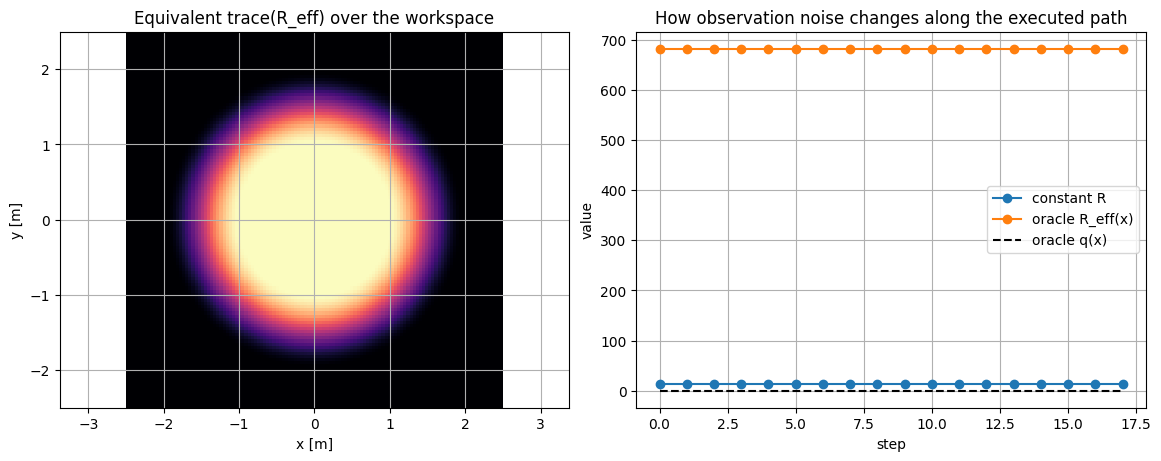

In [11]:
trace_r_good = float(np.trace(R_good))
trace_r_bad = float(np.trace(R_bad))
rtrace_map = q_map * trace_r_good + (1.0 - q_map) * trace_r_bad
oracle_rtrace = oracle_run["q_values"] * trace_r_good + (1.0 - oracle_run["q_values"]) * trace_r_bad
baseline_rtrace = np.full_like(oracle_rtrace, trace_r_good)

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.5), constrained_layout=True)

axes[0].imshow(rtrace_map, origin="lower", extent=extent, cmap="magma")
axes[0].set_title("Equivalent trace(R_eff) over the workspace")
axes[0].set_xlabel("x [m]")
axes[0].set_ylabel("y [m]")
axes[0].axis("equal")

axes[1].plot(baseline_rtrace, label="constant R", marker="o")
axes[1].plot(oracle_rtrace, label="oracle R_eff(x)", marker="o")
axes[1].plot(oracle_run["q_values"], label="oracle q(x)", linestyle="--", color="black")
axes[1].set_title("How observation noise changes along the executed path")
axes[1].set_xlabel("step")
axes[1].set_ylabel("value")
axes[1].legend()

plt.show()


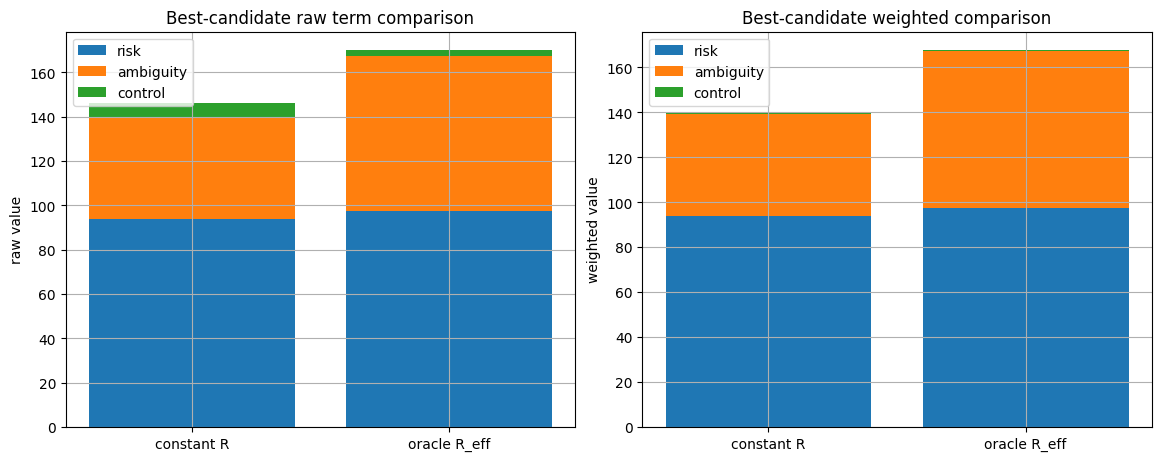

In [12]:
labels = ["constant R", "oracle R_eff"]
best_constant = baseline_candidates[0]
best_oracle = oracle_candidates[0]

raw_terms = np.array([
    [best_constant.risk_raw, best_constant.ambiguity_raw, best_constant.control_raw],
    [best_oracle.risk_raw, best_oracle.ambiguity_raw, best_oracle.control_raw],
])
weighted_terms = np.array([
    [best_constant.risk_term, best_constant.ambiguity_term, best_constant.control_term],
    [best_oracle.risk_term, best_oracle.ambiguity_term, best_oracle.control_term],
])
colors = ["tab:blue", "tab:orange", "tab:green"]
term_labels = ["risk", "ambiguity", "control"]
x = np.arange(len(labels))

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.5), constrained_layout=True)
bottom = np.zeros(len(labels))
for idx, term in enumerate(term_labels):
    axes[0].bar(x, raw_terms[:, idx], bottom=bottom, color=colors[idx], label=term)
    bottom = bottom + raw_terms[:, idx]
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels)
axes[0].set_title("Best-candidate raw term comparison")
axes[0].set_ylabel("raw value")
axes[0].legend()

bottom = np.zeros(len(labels))
for idx, term in enumerate(term_labels):
    axes[1].bar(x, weighted_terms[:, idx], bottom=bottom, color=colors[idx], label=term)
    bottom = bottom + weighted_terms[:, idx]
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels)
axes[1].set_title("Best-candidate weighted comparison")
axes[1].set_ylabel("weighted value")
axes[1].legend()

plt.show()


## Advantages, Limitations, Alternatives, Sources

Advantages:
- clean observation-model-only comparison,
- directly thesis-relevant,
- easy to promote into learned or map-based `q(x)` later.

Limitations:
- oracle `q(x)` is still hand-designed,
- no missed-detection Bernoulli model yet,
- no real-map structure yet.

Alternatives deliberately deferred:
- heuristic visibility penalties,
- covariance inflation terms,
- GP occupancy maps as the first mechanism.

Local anchors:
- [`diffdrivenav-bev2image-efe .ipynb`](diffdrivenav-bev2image-efe%20.ipynb)
- [`gp-visibility-efe-sandbox.ipynb`](gp-visibility-efe-sandbox.ipynb)
- [`state_dependent_observation_helpers.py`](state_dependent_observation_helpers.py)
- [`../docs/state_dependent_observation_plan.md`](../docs/state_dependent_observation_plan.md)

Background reading:
- Friston et al., *Active inference and epistemic value* (2015): https://pubmed.ncbi.nlm.nih.gov/25689102/
- Friston et al., *Active Inference, Curiosity and Insight* (2017): https://discovery.ucl.ac.uk/id/eprint/1570070/
